In [1]:
using Pkg
Pkg.activate(".")
Pkg.instantiate()
Pkg.resolve()

  Activating project at `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Project.toml`
  No Changes to `~/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/Manifest.toml`


In [2]:
using NPZ

using Distributions
using LinearAlgebra
using StatsFuns
using StatsBase

using LogDensityProblems
using LogDensityProblemsAD
using AbstractDifferentiation
using MCMCDiagnosticTools
using AdvancedHMC
using MicroCanonicalHMC
using Pathfinder
using Transducers

using Healpix
using HealpixMPI
using MPI

using Plots
using StatsPlots
using LaTeXStrings
using DataFrames

using Random
using ProgressMeter
using BenchmarkTools
using NPZ
using CSV
using Test
using Zygote: @adjoint
using Zygote
using ChainRules.ChainRulesCore

include("AD_parallSHT.jl")
include("gen_datatest.jl")
include("reparam.jl")
include("utils.jl")
include("inference_model.jl")
include("neglogproblem.jl")

nℓπ_grad (generic function with 1 method)

In [3]:
# files = filter(
#     f -> endswith(f, "_mask_NUTS_nside_16.npy"),
#     readdir("/Users/ethansmith/Desktop/Waterloo/Masters/Andrea_flinch_scripts/scripts/MPI_chains"; join=true)
# )

# for file in files
#     println(file)
# end

# sort!(files)

# sampled_params = hcat((npzread(f) for f in files)...)

pareto_shapes = npzread("/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/32000_16/2hJw3_2yjXc_Uwhcr_X053p_YClrY_aNW8N_dZqR8_frxOb_hsjv5_i7K0Z_nYEhC_onjaq_qNOsg_t8JDO_vs5sq_x6ksf/pareto_shapes.npy")

2384-element Vector{Float64}:
 0.7879669298835255
 0.6701739016733714
 0.3537631811342462
 1.1165144658635129
 0.6439735101887317
 0.7486213109179659
 0.5624514095952354
 0.9004777593580413
 0.8526911387162333
 0.35667394036921635
 ⋮
 0.16101794770986125
 0.5405969894893514
 0.5502196258426585
 0.2086544292893612
 0.365776500213253
 0.3834484757055761
 1.111214116855973
 0.5761098657899015
 0.4607713447707393

In [4]:
seed = 1123
Random.seed!(seed)

#   RESOLUTION PARAMETERS
nside = 16
lmax = 2*nside - 1

MPI.Init()

comm = MPI.COMM_WORLD
crank = MPI.Comm_rank(comm)
csize = MPI.Comm_size(comm)
root = 0
ncore = 32

#   REALIZATION MAP
realiz_Cl, realiz_HAlm, realiz_HMap = Realization("Capse_fiducial_Dl.csv", nside, lmax, seed)
realiz_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([realiz_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(realiz_Cl))

d = length(realiz_θ)

#   SURVEY MASK
mask_512 = readMapFromFITS("wmap_temperature_kq85_analysis_mask_r9_9yr_v5.fits",2,Float64)
mask_nside = udgrade(nest2ring(mask_512), nside)
for i in 1:length(mask_nside.pixels)
    if mask_nside.pixels[i]<=0.5
        mask_nside.pixels[i]=1
    else
        mask_nside.pixels[i]=0
    end
end

#   GENERATED DATA MEASUREMENTS
#   Noise
ϵ=150
N = ϵ*ones(nside2npix(nside))
N[mask_nside.==1] .= 5*10^4
#   Gaussian beam and pixel window function
Bl = ones(length(realiz_Cl))#gaussbeam(0.001, lmax, pol=false)
Pl = ones(length(realiz_Cl))#pixwin(nside, pol=false)[1:lmax+1]
BP_l = Bl.*Pl

#   Data Map
gen_Cl, gen_HAlm, gen_HMap = Measurement(realiz_Cl, Bl, Pl, mask_nside, N, nside, lmax, seed)
gen_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([gen_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(gen_Cl))
invN_HMap = HealpixMap{Float64,RingOrder}(1 ./ N)

#   STARTING POINT
start_Cl, start_HAlm, start_HMap = StartingPoint(gen_Cl, nside)
start_θ = vcat(x_vecmat2vec(from_healpix_alm_to_alm([start_HAlm], lmax, 1, comm, root=root), lmax, 1, comm, root=root), Cl2Kl(start_Cl))

#   PROMOTE HEALPIX.MAP TO HEALIPIXMPI.DMAP
gen_DMap = DMap{RR}(comm)
invN_DMap = DMap{RR}(comm)
HealpixMPI.Scatter!(gen_HMap, gen_DMap, comm, clear=true)
HealpixMPI.Scatter!(invN_HMap, invN_DMap, comm, clear=true)

helper_DMap = deepcopy(gen_DMap)

DMap: I am task 0 of 1, I work on 63 rings of 63
DMap: I am task 0 of 1, I work on 63 rings of 63


DMap{RR, Float64}([0.0; 0.0; … ; 106.75576281525872; 57.76576547614584;;], GeomInfoMPI(MPI.Comm(1140850688), 16, 64, [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25585245340993723, 2.885740200179856, 0.20448019896853478, 2.9371124546212584, 0.15324300949611616, 2.988349644093677, 0.10210642238260403, 3.039486231207189, 0.05103657515266638, 3.090556078437127], [32, 31, 33, 30, 34, 29, 35, 28, 36, 27  …  5, 59, 4, 60, 3, 61, 2, 62, 1, 63], [1, 65, 129, 193, 257, 321, 385, 449, 513, 577  …  2953, 2973, 2993, 3009, 3025, 3037, 3049, 3057, 3065, 3069], [64, 64, 64, 64, 64, 64, 64, 64, 64, 64  …  20, 20, 16, 16, 12, 12, 8, 8, 4, 4], [1.5707963267948966, 1.5291175943723188, 1.6124750592174744, 1.4873662401842815, 1.6542264134055116, 1.445468495626831, 1.696124157962962, 1.4033482475752073, 1.7382444060145859, 1.3609257345321588  …  0.25

In [5]:
pixels = length(gen_DMap.pixels)

3072

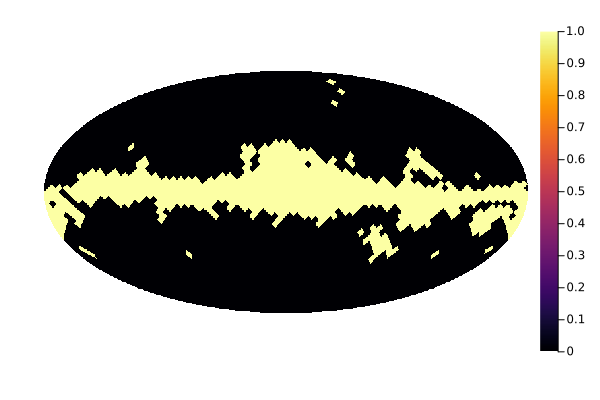

In [6]:
plot(mask_nside)

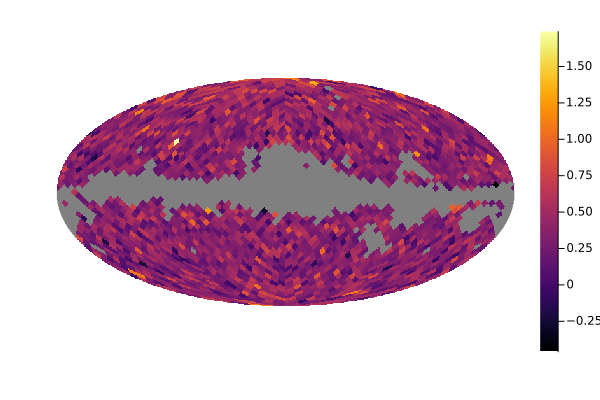

In [7]:
shape_mapping = deepcopy(mask_nside)

unmasked_index = 0
for pix in 1:pixels
    if shape_mapping[pix] != 1.0
        global unmasked_index += 1
        shape_mapping[pix] = pareto_shapes[unmasked_index]
    else
        shape_mapping[pix] = NaN
    end
end

shape_map = plot(shape_mapping)

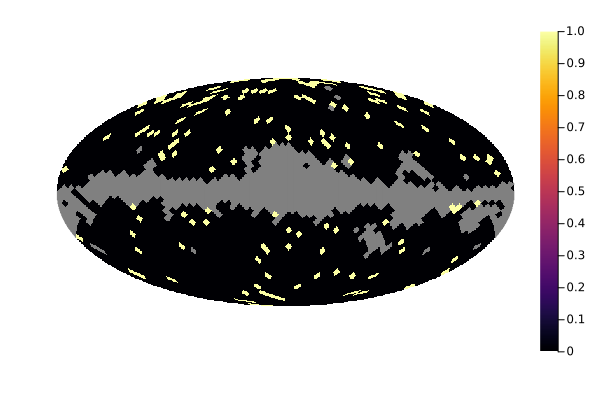

In [8]:
failure_mapping = deepcopy(mask_nside)

unmasked_index = 0
for pix in 1:pixels
    if failure_mapping[pix] != 1.0
        unmasked_index += 1
        if pareto_shapes[unmasked_index] > 0.7
            failure_mapping[pix] = 1.0
        else
            failure_mapping[pix] = 0.0
        end
    else
        failure_mapping[pix] = NaN
    end
end

failure_map = Plots.plot(failure_mapping)

In [9]:
Plots.savefig(failure_map, "/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/32000_16/2hJw3_2yjXc_Uwhcr_X053p_YClrY_aNW8N_dZqR8_frxOb_hsjv5_i7K0Z_nYEhC_onjaq_qNOsg_t8JDO_vs5sq_x6ksf/failure map.png")
Plots.savefig(shape_map, "/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/32000_16/2hJw3_2yjXc_Uwhcr_X053p_YClrY_aNW8N_dZqR8_frxOb_hsjv5_i7K0Z_nYEhC_onjaq_qNOsg_t8JDO_vs5sq_x6ksf/shape_map.png")

"/Users/ethansmith/Desktop/Waterloo/Masters/LOO_PIT_Manual/Flinch/scripts/PSIS_results/32000_16/2hJw3_2yjXc_Uwhcr_X053p_YClrY_aNW8N_dZqR8_frxOb_hsjv5_i7K0Z_nYEhC_onjaq_qNOsg_t8JDO_vs5sq_x6ksf/shape_map.png"